In [1]:
import os
import math
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from HDVClassNet.PP_net import PPNet
from HDVClassNet.VoronoiDecorder import VoronoiDecoder,VoronoiModelVisualizer
from Training.MainTrain import TrainingConfig, NN_Trainer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


gmesh was loaded successfully!
Code Directory: /home/arash/HDV_Shell
Test Step files Directory: /home/arash/HDV_Shell/Testparts
device: cuda
PyVista backend: trame


In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"


shape_path = FreeFormSurf1

# Meshing controls
# OCC meshing (global fallback for mode="mesh"):
#   - deflection: smaller -> finer OCC mesh
#   - angle: smaller -> finer OCC mesh on curved regions
# Manual UV-grid meshing (used when freeform_mesher="manual" on supported analytic faces):
#   - n_u, n_v: more samples -> finer UV grid mesh
# Gmsh meshing (used for free-form faces when freeform_mesher is "auto" or "gmsh"):
#   - gmsh_size_scale: smaller -> finer mesh, larger -> coarser mesh
#   - gmsh_algorithm: picks the Gmsh 2D meshing algorithm (6 is a solid default)
# Mesher selection:
#   - freeform_mesher="auto": try Gmsh first, then fall back to OpenCascade
#   - freeform_mesher="gmsh": require Gmsh for free-form faces
#   - freeform_mesher="manual": use UV-grid on supported analytic faces, otherwise OpenCascade

Case_name = shape_path.stem
print(Case_name)
generator = CADTensorGenerator(
    deflection=0.001,
    angle=0.001,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=100,
    n_v=100,
    freeform_mesher="auto",
    gmsh_size_scale=2.0,
    gmsh_algorithm=6,
    device=device,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=str(shape_path),
    input_ring=1,
    mode="mesh", #"1: mesh" "2:Sampled_points "
    M_per_face=2000,
    pool_size_factor=10,
    fps_pool_factor=4,
    use_fps=True,
    triangulation_max_edge_rel=0.1,
)

uv = tensors["uv"]
points_xyz = tensors["points_xyz"]
uv = tensors["uv"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
faces_ijk = tensors["faces_ijk"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
pv_faces = tensors["pv_faces"]
bbx_all = list(tensors["BBX"].values())



xmin = min(b["xmin"] for b in bbx_all)
xmax = max(b["xmax"] for b in bbx_all)
ymin = min(b["ymin"] for b in bbx_all)
ymax = max(b["ymax"] for b in bbx_all)
zmin = min(b["zmin"] for b in bbx_all)
zmax = max(b["zmax"] for b in bbx_all)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin


print(f"Number of faces: {tensors['num_faces']}")
print(f"Number of Sampled points: {uv.shape[0]}")
print(f"Global BBX dimensions: dx={dx:.4f}, dy={dy:.4f}, dz={dz:.4f}")

# Visualization follows the selected mesh path because it uses the returned
# `points_xyz` and `pv_faces` tensors directly.
# Increase visual resolution by changing the meshing parameters above:
#   - mode="mesh" + OCC: decrease deflection / angle
#   - mode="mesh" + manual UV: increase n_u / n_v
#   - mode="mesh" + Gmsh: decrease gmsh_size_scale
#   - mode="Sampled_points": increase M_per_face and optionally reduce
#     triangulation_max_edge_rel
viz.visualize_show_Model(points_xyz, pv_faces)


pts = points_xyz.detach().cpu().numpy()
cloud = pv.PolyData(pts)
plotter = pv.Plotter()
plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=6)
plotter.show()

FreeFormCrv1
Model is meshed using Gmsh tool
MinVolFrac: 0.09923742711544037
Number of faces: 1
Number of Sampled points: 3165
Global BBX dimensions: dx=6.1134, dy=6.5514, dz=2.6732


Widget(value='<iframe src="http://localhost:40575/index.html?ui=P_0x79b9ec303fa0_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:40575/index.html?ui=P_0x79b694910bb0_1&reconnect=auto" class="pyvi…

 Binirized values: tensor([3.0590e-07, 1.0000e+00, 1.0000e+00, 4.7426e-02, 1.0000e+00, 3.0590e-07,
        9.9988e-01, 9.5257e-01, 7.5826e-10, 1.0000e+00])
 Difference: tensor([-3.0590e-07,  0.0000e+00,  0.0000e+00, -4.7426e-02,  3.5763e-07,
        -3.0590e-07,  1.2338e-04,  4.7426e-02, -7.5826e-10,  0.0000e+00])


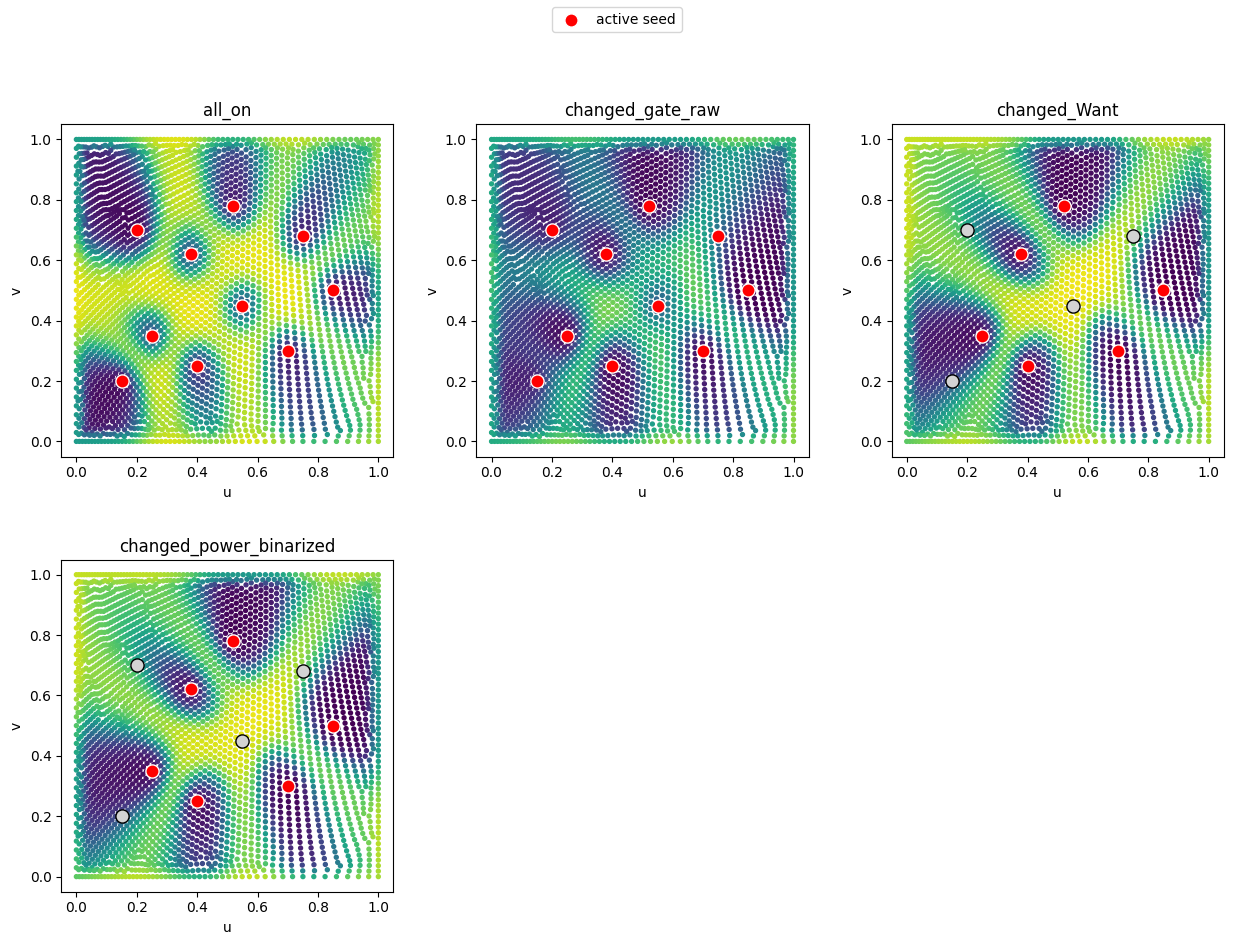

Widget(value='<iframe src="http://localhost:40575/index.html?ui=P_0x79b692ca2aa0_2&reconnect=auto" class="pyvi…

In [3]:

# fixed seeds
seeds_raw = torch.tensor([
    [0.15, 0.20],
    [0.25, 0.35],
    [0.40, 0.25],
    [0.55, 0.45],
    [0.70, 0.30],
    [0.20, 0.70],
    [0.38, 0.62],
    [0.52, 0.78],
    [0.75, 0.68],
    [0.85, 0.50],
], dtype=torch.float32)

S = seeds_raw.shape[0]

# symmetric pairwise widths
w_raw = torch.full((S, S), 0.2, dtype=torch.float32)
w_raw = 0.5 * (w_raw + w_raw.T)

# optional anisotropy
theta = torch.zeros(S, dtype=torch.float32)
a_raw = torch.zeros(S, dtype=torch.float32)

Veron_viz = VoronoiModelVisualizer(
    points_uv=uv,
    Xu=Xu,
    Xv=Xv,
    points_xyz=points_xyz,
    faces_ijk=faces_ijk,
    tau=0.1,
    n_seeds=S,
    use_metric_anisotropy=True,
    fixed_height=0.2,
    use_boundary_attachment=True,
)

changed_raw = torch.tensor([0.2, 0.8, 0.9, 0.4, 0.7, 0.2, 0.6, 0.5, 0.1, 1], dtype=torch.float32)
changed_Want = torch.tensor([0, 1, 1, 0, 1, 0, 1, 1, 0, 1], dtype=torch.float32)
#Binirized_gate = torch.sigmoid((changed_gate)>0.6)
t = 0.45
k = 60.0
binarized_gate = torch.sigmoid(k * (changed_raw - t))
Difference = changed_Want-binarized_gate
print(f" Binirized values: {binarized_gate}")
print(f" Difference: {Difference}")
gate_vectors = {
    "all_on": torch.ones(S, dtype=torch.float32),
    "changed_gate_raw": changed_raw,
    "changed_Want": changed_Want,
    "changed_power_binarized": binarized_gate,
}

result = Veron_viz.visualize(
    seeds_raw=seeds_raw,
    gate_vectors=gate_vectors,
    w_raw=w_raw,
    theta=theta,
    a_raw=a_raw,

    # boundary inputs provided here
    boundary_uv = tensors["uv"][tensors["boundary_idx"]],
    boundary_face_id = tensors["face_id"][tensors["boundary_idx"]],
    boundary_width_raw=torch.tensor(0.0),
    boundary_alpha_raw=torch.tensor(0.0),
    boundary_beta_raw=torch.tensor(0.0),

    show_uv=True,
    show_3d=True,
)

display(result["uv_fig"])
result["plotter"].show()

In [4]:
fixed_height_shell= 0.2
# shell_problem = ThickenShell(
#     thickness=fixed_height_shell,
#     BC_dir = "y",
#     Load_magnitude=0.0001,
#     voxel_size=0.1,
#     extra_layers=1,
#     tensors=tensors,
#     tangential_tol=0.1,
# )
shell_problem =None
fem =None
# fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
# shell_problem.debug_voxel_stats()
# shell_problem.show_voxels_surface_and_bc()

In [5]:
cfg = TrainingConfig(
    # ============================================================
    # Seed / geometry setup
    # ============================================================
    seed_number=25,
    use_Metric_anisotropy=False,
    fixed_height=fixed_height_shell,
    freeze_w=False,
    w_min=05e-6,
    # Pairwise strut widths now use w_max_ij = 0.8 * seed_distance(i, j).
    use_boundary_attachment=False,
    boundary_vol_weight = 0.5,
    use_boundary_weighted_volume=False,


    # fallback / initialization ranges used by decoder maps
    boundary_attach_alpha = 1.0,
    boundary_attach_width = 0.01,
    boundary_attach_beta = 0.005,

    boundary_attach_width_min=05e-6,
    boundary_attach_width_max=5e-5,

    # PPNet predicts these now
    predict_boundary_width=False,

    # ============================================================
    # Main geometric / physical target
    # ============================================================
    target_volfrac=0.2,

    # ============================================================
    # Geometric regularization terms
    # ============================================================
    seed_repulsion_sigma=0.08,
    boundary_margin=0.05,

    # ============================================================
    # Core loss weights
    # ============================================================
    lam_fem=0.0,
    lam_vol=20.0,
    lam_rep=0.015,
    lam_bnd=0.0,
    lam_strut=0.0005,
    lam_strut_edge=0.0,
    lam_strut_void=0.2,

    # ============================================================
    # Gate losses
    # ============================================================
    use_gating=True,
    lam_gate_count=0.005,
    lam_gate_binary=0.1,
    gate_target_count=10.0,
    gate_warmup_steps=2,
    gate_binary_warmup_steps=2,
    gate_sharpen_gamma=2.0,
    gate_active_threshold=0.3,
    gate_eps=1e-8,
    gate_bias_init=2.0,
    Gating_binirize_sharpness= 60.0,
    Gating_binirize_limit=0.45,
    use_hard_gate_mask = True,
    hard_gate_start_frac = 0.90,
    hard_gate_stability_patience = 150,

    # ============================================================
    # Learning rates
    # ============================================================
    lr_seed_refine=0.003,
    lr_delta_head=1e-4,
    lr_mlp=2e-4,
    lr_w_head=2e-3,
    lr_h_head=2e-4,
    lr_gate_head=5e-5,
    lr_boundary_heads=5e-4,

    # ============================================================
    # FEM / normalization
    # ============================================================
    comp_normalize_by=None,
    normalize_losses=False,
    fem_density_floor=0.02,
    skip_bad_fem_steps=True,

    # ============================================================
    # Optimization schedule
    # ============================================================
    num_steps=5000,
    context_vector_size=8,
    log_every=100,
    early_stop_start=1000,
    patience=200,
    min_delta=1e-10,

    # ============================================================
    # Decoder softness / geometry shaping
    # ============================================================
    tau=0.1,
    beta=0.02,

    # ============================================================
    # Scheduler / training stability
    # ============================================================
    scheduler_milestones=(0.9,),
    scheduler_gamma=0.2,
    Offset_scale=5,
    save_fem_debug_history=True,
    grad_clip_norm=1.0,

    # ============================================================
    # TensorBoard logging
    # ============================================================
    experiment_name=str(Case_name),
    tensorboard_enabled=True,
    tb_log_histograms_every=100,

    # ============================================================
    # Timelapse / visualization
    # ============================================================
    MakeTimelaps=True,
    timelapse_frame_step=10,
    TM_laps_res_u=150,
    TM_laps_res_v=150,
    TM_laps_Thr=0.25,
)

trainer = NN_Trainer(
    generator=generator,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
)

print(cfg)

result = trainer.train(
    shape_path,
    face_tensors=tensors["face_tensors"],
)

TensorBoard log dir: runs/FreeFormCrv1
TrainingConfig(seed_number=25, use_Metric_anisotropy=False, fixed_height=0.2, target_volfrac=0.2, seed_repulsion_sigma=0.08, boundary_margin=0.05, freeze_w=False, use_boundary_attachment=False, boundary_volume_assist=0.1, boundary_attach_width=0.01, boundary_attach_beta=0.005, boundary_attach_alpha=1.0, boundary_attach_width_min=5e-06, boundary_attach_width_max=5e-05, boundary_attach_alpha_min=0.05, boundary_attach_alpha_max=1.0, boundary_attach_beta_min=0.003, boundary_attach_beta_max=0.05, gate_sharpen_gamma=2.0, w_min=5e-06, w_max=0.5, lam_fem=0.0, lam_vol=20.0, lam_rep=0.015, lam_bnd=0.0, lam_strut=0.0005, lam_strut_edge=0.0, lam_strut_void=0.2, comp_normalize_by=None, normalize_losses=False, fem_density_floor=0.02, skip_bad_fem_steps=True, num_steps=5000, context_vector_size=8, tau=0.1, beta=0.02, lr_seed_refine=0.003, lr_delta_head=0.0001, lr_mlp=0.0002, lr_w_head=0.002, lr_h_head=0.0002, lr_boundary_heads=0.0005, log_every=100, early_stop_s

Training:   0%|          | 0/5000 [00:00<?, ?it/s]

New best_step=0 | best_score=8.714617 | vol_eff=0.624341 | comp=0.000000e+00 | w=2.462941e-01
[00000] | active(total/mean)=25/25.00 | hard_gate=off | gate_raw(min/mean/max)=0.881/0.881/0.881 | gate_sharp(min/mean/max)=1.000/1.000/1.000 | gate_dec(min/mean/max)=1.000/1.000/1.000 | L_total=8.7146e+00 | L_vol=4.357e-01 L_fem=0.000e+00 L_strut=0.000e+00 L_rep=1.658e-03 L_bnd=4.158e-01 L_gate=1.445e+02 L_gbin=0.000e+00 | vol=0.761 vol_eff=0.624 (/0.200) comp=0.000e+00 | w=2.463e-01 h=2.000e-01 | bw=0.000e+00 ba=0.000e+00 bb=0.000e+00 | theta=0.000e+00 a=0.000e+00 | Lse=1.121e-01 Lsv=0.000e+00 | rho(min/mean/max)=0.018/0.750/0.976 rho_b(min/mean/max)=0.000/0.000/0.000 rho_v(min/mean/max)=0.018/0.750/0.976 | Δrho=0.00e+00 Δseed=0.00e+00 grad_mean=6.80e-02 | fem=OK | best=8.7146e+00@0
[00100] | active(total/mean)=25/25.00 | hard_gate=off | gate_raw(min/mean/max)=0.475/0.493/0.509 | gate_sharp(min/mean/max)=0.817/0.922/0.972 | gate_dec(min/mean/max)=0.817/0.922/0.972 | L_total=1.1655e+00 | L_vo

In [6]:
trainer.visualize_result_stepwise(result, points_xyz, faces_ijk)
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=0.5, show_solid=False)

Widget(value='<iframe src="http://localhost:40575/index.html?ui=P_0x79b694910c70_3&reconnect=auto" class="pyvi…

threshold=0.5 (manual) | solid%=22.970%


Widget(value='<iframe src="http://localhost:40575/index.html?ui=P_0x79b40b5568f0_4&reconnect=auto" class="pyvi…

(UnstructuredGrid (0x79b40b521480)
   N Cells:    1538
   N Points:   866
   X Bounds:   -1.052e+00, 2.950e+00
   Y Bounds:   -9.347e-02, 4.416e+00
   Z Bounds:   3.903e-01, 1.537e+00
   N Arrays:   3,
 0.5)

In [9]:
AA = result["best_pred"]
BB0 = AA[0]["gate_probs"]          # gate_probs for first face
g_soft = torch.sigmoid(60* (BB0 - 0.45))
best_seeds = result["best_seeds"]   # list, one tensor per face
seeds_face0 = best_seeds[0]         # shape: (S, 2)

print(BB0)
print(g_soft)
print(seeds_face0)



tensor([0.3154, 0.0330, 0.9610, 0.0151, 0.5827, 0.4093, 0.0124, 0.0983, 0.8930,
        0.1589, 0.8085, 0.9190, 0.0235, 0.1278, 0.3965, 0.8678, 0.1312, 0.0176,
        0.4997, 0.0487, 0.0258, 0.8249, 0.9414, 0.0654, 0.8797],
       device='cuda:0')
tensor([3.1057e-04, 1.3603e-11, 1.0000e+00, 4.6532e-12, 9.9965e-01, 8.0173e-02,
        3.9605e-12, 6.8494e-10, 1.0000e+00, 2.6027e-08, 1.0000e+00, 1.0000e+00,
        7.7099e-12, 4.0220e-09, 3.8883e-02, 1.0000e+00, 4.9286e-09, 5.4095e-12,
        9.5181e-01, 3.4849e-11, 8.8365e-12, 1.0000e+00, 1.0000e+00, 9.5390e-11,
        1.0000e+00], device='cuda:0')
tensor([[0.0051, 0.3374],
        [0.8788, 0.8901],
        [0.8594, 0.0086],
        [0.2172, 0.8798],
        [0.2867, 0.2477],
        [0.8768, 0.4595],
        [0.0186, 0.8670],
        [0.4903, 0.6476],
        [0.0794, 0.0089],
        [0.1137, 0.4966],
        [0.5958, 0.1526],
        [0.3186, 0.0096],
        [0.6029, 0.8878],
        [0.2785, 0.5646],
        [0.5045, 0.3954],
   

In [11]:
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=0.4, show_solid=False)

threshold=0.4 (manual) | solid%=27.393%


Widget(value='<iframe src="http://localhost:40575/index.html?ui=P_0x79b40b4f5e40_8&reconnect=auto" class="pyvi…

(UnstructuredGrid (0x79b40b5a0ee0)
   N Cells:    1804
   N Points:   1003
   X Bounds:   -1.176e+00, 3.000e+00
   Y Bounds:   -1.709e-01, 4.416e+00
   Z Bounds:   3.731e-01, 1.568e+00
   N Arrays:   3,
 0.4)

In [7]:
trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)
print(result["tensorboard_log_dir"])

Widget(value='<iframe src="http://localhost:40575/index.html?ui=P_0x79b40b3f2e60_5&reconnect=auto" class="pyvi…

runs/FreeFormCrv1


In [ ]:
# Increase `dense_factor` for denser UV debug sampling.
dbg = trainer.visualize_boundary_attachment_debug(
    result=result,
    shape_or_path=str(shape_path),
    face_index=0,      # change if needed
    grid_res_u=50,
    grid_res_v=50,
    dense_factor=1.0,
)


In [ ]:
# Increase `dense_factor` to get a denser smooth point visualization.
smooth = trainer.visualize_result_final_smooth_points(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.1,
    grid_res_u=100,
    grid_res_v=1,
    dense_factor=2.0,
)

In [ ]:
trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)
print(result["tensorboard_log_dir"])

In [ ]:
# Increase `dense_factor` to refine the CAD-native smooth surface display.
out = trainer.visualize_result_final_smooth_surface_pyvista(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.55,
    grid_res_u=300,
    grid_res_v=300,
    dense_factor=2.0,
)
print(out["thr_used"], out["volfrac_thr"])

In [ ]:
for t in [0.01,0.05,0.1,0.15,0.25,0.35,0.45,0.5]:    
    out = trainer.visualize_result_final_smooth_surface_pyvista(
        result=result,
        shape_or_path=str(shape_path),
        thr=t ,
        grid_res_u=300,
        grid_res_v=300,
        dense_factor=1.0,
    )
    print(out["thr_used"], out["volfrac_thr"])



In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs